# BiGRU Baseline Model with Grey Wolf Optimizer (GWO) Integration
## 1-Layer Bidirectional GRU — Unified Notebook

**Architecture**: Embedding → Bidirectional GRU → Dense(sigmoid)  
**Optimization**: Grey Wolf Optimizer (GWO) for hyperparameter tuning  

---
### Notebook Structure
1. Environment Configuration & Imports  
2. Data Loading  
3. Dataset Statistics  
4. Model Architecture  
5. Helper Functions  
6. Callbacks & Training Utilities  
7. Baseline Training  
8. GWO Hyperparameter Optimization  
9. Final Model Training (Optimized)  
10. Evaluation & Comparison  
11. Visualization  



## 1. Environment Configuration & Imports

In [3]:
import os


# Environment Variables 

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"        # Use GPU 0 and 1; set "0" for single GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"           # Suppress TF C++ logs (INFO/WARNING)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"          # Disable OneDNN for numerical stability
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_USE_LEGACY_KERAS"] = "1"



# Standard Library Imports

import warnings
import random
import time
from datetime import timedelta
from typing import Dict, Tuple, List, Optional


# Third-Party Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score
)

from mealpy.swarm_based.GWO import OriginalGWO
from mealpy import FloatVar, IntegerVar

warnings.filterwarnings("ignore")

print(f"TensorFlow version : {tf.__version__}")
print(f"CUDA built         : {tf.test.is_built_with_cuda()}")
print("All imports successful.")


TensorFlow version : 2.21.0
CUDA built         : True
All imports successful.


## 2. Reproducibility & GPU Setup

In [4]:

# Random Seed Configuration

RANDOM_STATE = 116


def set_seeds(seed: int = RANDOM_STATE) -> None:
    """Set all random seeds for full reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)  # Hash-based ops (dicts, sets)



# GPU Memory Growth

def setup_gpu():
    """Configure TensorFlow GPU memory growth."""
    
    gpus = tf.config.list_physical_devices("GPU")

    if not gpus:
        print("No GPU detected. Using CPU.")
        return

    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices("GPU")

        print(f"GPUs available: {len(gpus)} physical | {len(logical_gpus)} logical")

    except RuntimeError as e:
        print("GPU setup failed:", e)


set_seeds(RANDOM_STATE)
setup_gpu()


GPUs available: 1 physical | 1 logical


I0000 00:00:1774348864.011452  701257 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:65:00.0, compute capability: 8.9


## 3. Global Configuration

In [5]:

# Dataset Paths — Update paths to match your environment

DATA_PATHS = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "val"  : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx",
    "test" : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
}


# Training Hyperparameters (Baseline)

EPOCHS      = 100
PATIENCE    = 5
RANDOM_STATE = 116

BASELINE_PARAMS = {
    "learning_rate": 3e-4,
    "batch_size"   : 256,
    "gru_units"    : 32,
    "dropout"      : 0.3,
}


# GWO Search Space & Configuration

GWO_CONFIG = {
    "pop_size": 10,
    "epoch"   : 10,
}

SEARCH_SPACE = {
    "learning_rate": (1e-5, 1e-2),
    "batch_size"   : (64, 512),
    "gru_units"    : (16, 128),
    "dropout"      : (0.1, 0.5),
}


# Output Directories

MODEL_NAME  = "BiGRU_Baseline"

DIRS = {
    "models" : "./models",
    "results": "./results",
    "plots"  : "./plots",
    "gwo"    : "./gwo_results",
    "images" : "./images",
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Derived save paths
BASELINE_MODEL_PATH  = f"{DIRS['models']}/{MODEL_NAME}_baseline.keras"
OPTIMIZED_MODEL_PATH = f"{DIRS['models']}/{MODEL_NAME}_optimized.keras"
MODEL_ARCHITECTURE   = f"{DIRS['images']}/{MODEL_NAME}_architecture.png"

print("Configuration loaded.")
print(f"  Baseline model will save to : {BASELINE_MODEL_PATH}")
print(f"  Optimized model will save to: {OPTIMIZED_MODEL_PATH}")


Configuration loaded.
  Baseline model will save to : ./models/BiGRU_Baseline_baseline.keras
  Optimized model will save to: ./models/BiGRU_Baseline_optimized.keras


## 4. Data Loading

In [6]:

# Dataset Loader


def load_dataset(path: str, name: str) -> Tuple[np.ndarray, np.ndarray]:
    """Load dataset from Excel file and return features and labels as NumPy arrays."""
    
    df = pd.read_excel(path)

    X = df.drop(columns="labels").apply(pd.to_numeric, errors="coerce").fillna(0)
    y = pd.to_numeric(df["labels"], errors="coerce").fillna(0)

    X = np.asarray(X, dtype=np.int32)
    y = np.asarray(y, dtype=np.int32)

    label_counts = pd.Series(y).value_counts().rename(index={0: "Negative", 1: "Positive"})

    print(f"{name.upper():5s} | samples={X.shape[0]:,}  seq_len={X.shape[1]}  ", end="")
    print(f"dtype: X={X.dtype} y={y.dtype}")
    print(f"       label dist: {label_counts.to_dict()}")

    return X, y



# Load Datasets

print("LOADING DATASETS")


X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_val,   y_val   = load_dataset(DATA_PATHS["val"],   "val")
X_test,  y_test  = load_dataset(DATA_PATHS["test"],  "test")




LOADING DATASETS
TRAIN | samples=8,260  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Negative': 4167, 'Positive': 4093}
VAL   | samples=1,806  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 913, 'Negative': 893}
TEST  | samples=1,833  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 940, 'Negative': 893}


## 5. Dataset Statistics

In [7]:

# Vocabulary Size & Sequence Length

VOCAB_SIZE = int(max(X_train.max(), X_val.max(), X_test.max()))
MAX_LEN    = X_train.shape[1]

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Training samples  : {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Test samples      : {X_test.shape[0]:,}")
print(f"Vocabulary size   : {VOCAB_SIZE:,}")
print(f"Sequence length   : {MAX_LEN}")
print(f"Positive (train)  : {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Positive (val)    : {y_val.sum():,}   ({y_val.mean()*100:.1f}%)")
print(f"Positive (test)   : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")
print("=" * 60)


DATASET STATISTICS
Training samples  : 8,260
Validation samples: 1,806
Test samples      : 1,833
Vocabulary size   : 132
Sequence length   : 271
Positive (train)  : 4,093 (49.6%)
Positive (val)    : 913   (50.6%)
Positive (test)   : 940  (51.3%)


## 6. Model Architecture

In [ ]:

# Model Builder — parametric for GWO compatibility
def build_model(
    vocab_size : int,
    max_len    : int,
    gru_units  : int   = 32,
    dropout    : float = 0.3,
    seed       : int   = RANDOM_STATE,
) -> Sequential:

    set_seeds(seed)

    model = Sequential([
        Embedding(
            input_dim    = vocab_size + 1,
            output_dim   = 128,
            input_length = max_len,
            mask_zero    = False,
        ),
        Bidirectional(
            GRU(gru_units, return_sequences=False, dropout=dropout)
        ),
        Dense(1, activation="sigmoid"),
    ], name="BiGRU_Baseline")

    return model



# Preview architecture

_preview = build_model(VOCAB_SIZE, MAX_LEN)
_preview.build(input_shape=(None, MAX_LEN))
_preview.summary()

plot_model(_preview, to_file=MODEL_ARCHITECTURE, show_shapes=True, show_layer_names=True)
print(f"Architecture diagram saved to: {MODEL_ARCHITECTURE}")
del _preview


Model: "BiGRU_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 271, 128)       │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,193 (188.25 KB)

 Trainable params: 48,193 (188.25 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Architecture diagram saved to: ./images/BiGRU_Baseline_architecture.png


## 7. Helper Functions

In [9]:

# Metrics Helper


class ClassificationMetrics:
    """
    Compute and store standard binary classification metrics.

    Usage
    -----
    cm = ClassificationMetrics(y_true, y_pred)
    print(cm.report())
    """

    def __init__(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        self.y_true = y_true.flatten()
        self.y_pred = y_pred.flatten()
        self._cm    = confusion_matrix(self.y_true, self.y_pred)

    def confusion_matrix(self) -> np.ndarray:
        return self._cm

    def tp(self) -> int:
        return int(self._cm[1, 1])

    def tn(self) -> int:
        return int(self._cm[0, 0])

    def fp(self) -> int:
        return int(self._cm[0, 1])

    def fn(self) -> int:
        return int(self._cm[1, 0])

    def precision(self) -> float:
        return float(precision_score(self.y_true, self.y_pred, zero_division=0))

    def recall(self) -> float:
        return float(recall_score(self.y_true, self.y_pred, zero_division=0))

    def f1(self) -> float:
        return float(f1_score(self.y_true, self.y_pred, zero_division=0))

    def accuracy(self) -> float:
        return float(accuracy_score(self.y_true, self.y_pred))

    def as_dict(self) -> Dict:
        return {
            "Accuracy" : self.accuracy(),
            "Precision": self.precision(),
            "Recall"   : self.recall(),
            "F1-Score" : self.f1(),
            "TP": self.tp(), "TN": self.tn(),
            "FP": self.fp(), "FN": self.fn(),
        }

    def report(self, title: str = "Classification Metrics") -> str:
        d = self.as_dict()
        lines = ["=" * 50, title, "=" * 50]
        for k, v in d.items():
            lines.append(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")
        lines.append("=" * 50)
        return "".join(lines)



# Utility

def to_numpy(x) -> np.ndarray:
    """Convert pandas DataFrame/Series to numpy array if needed."""    
    return x.values if hasattr(x, "values") else x


print("Helper classes/functions defined.")


Helper classes/functions defined.


## 8. Baseline Training

In [10]:

# Clear any previous session before baseline training

tf.keras.backend.clear_session()
set_seeds(RANDOM_STATE)
tf.config.optimizer.set_jit(False)   # Disable XLA/JIT (prevents libdevice errors)

print("=" * 60)
print("BASELINE MODEL TRAINING")
print("=" * 60)
print(f"  LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Dropout={BASELINE_PARAMS['dropout']}")
print("=" * 60)

# Build 
baseline_model = build_model(
    vocab_size = VOCAB_SIZE,
    max_len    = MAX_LEN,
    gru_units  = BASELINE_PARAMS["gru_units"],
    dropout    = BASELINE_PARAMS["dropout"],
)

# Compile 
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

baseline_model.compile(
    optimizer  = Adam(learning_rate=BASELINE_PARAMS["learning_rate"]),
    loss       = loss_fn,
    metrics    = ["accuracy", tf.keras.metrics.AUC(name="auc")],
    run_eagerly= False,
)

baseline_model.build(input_shape=(None, MAX_LEN))
baseline_model.summary()

# Callbacks 
baseline_callbacks = [
    EarlyStopping(
        monitor             = "val_auc",
        mode                = "max",
        patience            = PATIENCE,
        restore_best_weights= True,
        verbose             = 1,
    ),
    ModelCheckpoint(
        filepath       = BASELINE_MODEL_PATH,
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

# Train 
baseline_start = time.time()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BASELINE_PARAMS["batch_size"],
    callbacks       = baseline_callbacks,
    verbose         = 2,
)

baseline_time = time.time() - baseline_start

print(f"Baseline training completed in {str(timedelta(seconds=int(baseline_time)))}")
print(f"Best model saved to: {BASELINE_MODEL_PATH}")


BASELINE MODEL TRAINING
  LR=0.0003  Batch=256  GRU=32  Dropout=0.3


Model: "BiGRU_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 271, 128)       │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,193 (188.25 KB)

 Trainable params: 48,193 (188.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1774348908.298878  701481 cuda_dnn.cc:461] Loaded cuDNN version 92000



Epoch 1: val_auc improved from None to 0.86990, saving model to ./models/BiGRU_Baseline_baseline.keras
33/33 - 6s - 185ms/step - accuracy: 0.7219 - auc: 0.8038 - loss: 0.1516 - val_accuracy: 0.7763 - val_auc: 0.8699 - val_loss: 0.1270
Epoch 2/100

Epoch 2: val_auc improved from 0.86990 to 0.90594, saving model to ./models/BiGRU_Baseline_baseline.keras
33/33 - 8s - 229ms/step - accuracy: 0.8029 - auc: 0.8724 - loss: 0.1159 - val_accuracy: 0.8355 - val_auc: 0.9059 - val_loss: 0.0999
Epoch 3/100

Epoch 3: val_auc improved from 0.90594 to 0.93513, saving model to ./models/BiGRU_Baseline_baseline.keras
33/33 - 2s - 66ms/step - accuracy: 0.8421 - auc: 0.9052 - loss: 0.0969 - val_accuracy: 0.8704 - val_auc: 0.9351 - val_loss: 0.0793
Epoch 4/100

Epoch 4: val_auc improved from 0.93513 to 0.95403, saving model to ./models/BiGRU_Baseline_baseline.keras
33/33 - 1s - 35ms/step - accuracy: 0.8805 - auc: 0.9349 - loss: 0.0769 - val_accuracy: 0.9059 - val_auc: 0.9540 - val_loss: 0.0619
Epoch 5/100



In [11]:

# Baseline Evaluation


# Validation set
baseline_val_pred = (baseline_model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
baseline_val_cm   = ClassificationMetrics(y_val, baseline_val_pred)

# Test set
baseline_test_pred = (baseline_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
baseline_test_cm   = ClassificationMetrics(y_test, baseline_test_pred)

print(baseline_val_cm.report("BASELINE — Validation Set"))
print()
print(baseline_test_cm.report("BASELINE — Test Set"))
print(f"Training time: {str(timedelta(seconds=int(baseline_time)))}")


==================================================BASELINE — Validation Set==================================================  Accuracy    : 0.9291  Precision   : 0.9769  Recall      : 0.8806  F1-Score    : 0.9263  TP          : 804  TN          : 874  FP          : 19  FN          : 109==================================================

==================================================BASELINE — Test Set==================================================  Accuracy    : 0.9318  Precision   : 0.9744  Recall      : 0.8904  F1-Score    : 0.9305  TP          : 837  TN          : 871  FP          : 22  FN          : 103==================================================
Training time: 0:03:38


## 9. Grey Wolf Optimizer (GWO) Integration

In [12]:

# Search Space 

gwo_bounds = [
    FloatVar  (lb=SEARCH_SPACE["learning_rate"][0], ub=SEARCH_SPACE["learning_rate"][1], name="learning_rate"),
    IntegerVar(lb=SEARCH_SPACE["batch_size"][0],    ub=SEARCH_SPACE["batch_size"][1],    name="batch_size"),
    IntegerVar(lb=SEARCH_SPACE["gru_units"][0],     ub=SEARCH_SPACE["gru_units"][1],     name="gru_units"),
    FloatVar  (lb=SEARCH_SPACE["dropout"][0],       ub=SEARCH_SPACE["dropout"][1],       name="dropout"),
]

print("GWO Search Space:")
for k, (lo, hi) in SEARCH_SPACE.items():
    print(f"  {k:<15}: [{lo}, {hi}]")


# Optimization State 

_gwo_iteration   = 0
_gwo_best_f1     = 0.0
_optimization_log: List[Dict] = []


def objective_function(solution: np.ndarray) -> float:

    global _gwo_iteration, _gwo_best_f1

    _gwo_iteration += 1

    lr         = float(solution[0])
    batch_size = int(np.clip(round(solution[1]), 32, 512))
    gru_units  = int(np.clip(round(solution[2]),  8, 128))
    dropout    = float(solution[3])

    print(f"[GWO iter {_gwo_iteration:>3}] LR={lr:.2e}  Batch={batch_size}  GRU={gru_units}  Drop={dropout:.3f}", end="  ")

    try:
        tf.keras.backend.clear_session()
        set_seeds(RANDOM_STATE)

        model = build_model(VOCAB_SIZE, MAX_LEN, gru_units=gru_units, dropout=dropout)

        loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)
        model.compile(
            optimizer   = Adam(learning_rate=lr),
            loss        = loss_fn,
            metrics     = ["accuracy", tf.keras.metrics.AUC(name="auc")],
            run_eagerly = False,
        )

        early_stop = EarlyStopping(
            monitor              = "val_auc",
            mode                 = "max",
            patience             = 3,
            restore_best_weights = True,
            verbose              = 0,
        )

        hist = model.fit(
            X_train, y_train,
            validation_data = (X_val, y_val),
            epochs          = 30,            
            batch_size      = batch_size,
            callbacks       = [early_stop],
            verbose         = 0,
        )

        y_pred  = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        f1_val  = f1_score(y_val, y_pred, zero_division=0)
        acc_val = accuracy_score(y_val, y_pred)

        if f1_val > _gwo_best_f1:
            _gwo_best_f1 = f1_val
            print(f"NEW BEST  F1={f1_val:.4f}  Acc={acc_val:.4f}")
        else:
            print(f"F1={f1_val:.4f}  Acc={acc_val:.4f}")

        _optimization_log.append({
            "iteration"   : _gwo_iteration,
            "learning_rate": lr,
            "batch_size"  : batch_size,
            "gru_units"   : gru_units,
            "dropout"     : dropout,
            "f1_score"    : f1_val,
            "accuracy"    : acc_val,
            "epochs_run"  : len(hist.history["loss"]),
        })

        return -f1_val   # GWO minimises

    except Exception as exc:
        print(f"ERROR: {exc}")
        return 0.0       # Worst possible fitness


print("Objective function defined.")


GWO Search Space:
  learning_rate  : [1e-05, 0.01]
  batch_size     : [64, 512]
  gru_units      : [16, 128]
  dropout        : [0.1, 0.5]
Objective function defined.


In [13]:
# Run GWO Optimisation

print("" + "=" * 60)
print("STARTING GWO OPTIMISATION")
print("=" * 60)
print(f"  Population : {GWO_CONFIG['pop_size']}")
print(f"  Epochs     : {GWO_CONFIG['epoch']}")
print(f"  Total evals: {GWO_CONFIG['pop_size'] * GWO_CONFIG['epoch']}")
print("=" * 60 + "")

gwo_problem = {
    "obj_func": objective_function,
    "bounds"  : gwo_bounds,
    "minmax"  : "min",
}

gwo_optimizer = OriginalGWO(
    epoch    = GWO_CONFIG["epoch"],
    pop_size = GWO_CONFIG["pop_size"],
)

gwo_start = time.time()
g_best    = gwo_optimizer.solve(gwo_problem)
gwo_time  = time.time() - gwo_start

best_solution = g_best.solution
best_fitness  = g_best.target.fitness

print("" + "=" * 60)
print("GWO OPTIMISATION COMPLETED")
print("=" * 60)
print(f"  Time elapsed  : {str(timedelta(seconds=int(gwo_time)))}")
print(f"  Best Val F1   : {-best_fitness:.4f}")
print("=" * 60)

# ── Save optimisation log ─────────────────────────────────
log_df = pd.DataFrame(_optimization_log)
gwo_log_path = f"{DIRS['gwo']}/{MODEL_NAME}_gwo_log.csv"
log_df.to_csv(gwo_log_path, index=False)
print(f"Optimisation log saved to: {gwo_log_path}")


2026/03/24 05:45:27 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=10)


STARTING GWO OPTIMISATION
  Population : 10
  Epochs     : 10
  Total evals: 100
[GWO iter   1] LR=6.53e-05  Batch=489  GRU=62  Drop=0.153  NEW BEST  F1=0.9133  Acc=0.9175
[GWO iter   2] LR=5.16e-03  Batch=94  GRU=17  Drop=0.460  NEW BEST  F1=0.9325  Acc=0.9352
[GWO iter   3] LR=7.33e-03  Batch=460  GRU=18  Drop=0.150  F1=0.9266  Acc=0.9280
[GWO iter   4] LR=8.06e-03  Batch=476  GRU=107  Drop=0.327  F1=0.9298  Acc=0.9319
[GWO iter   5] LR=7.98e-04  Batch=444  GRU=113  Drop=0.440  F1=0.8960  Acc=0.8959
[GWO iter   6] LR=3.60e-03  Batch=470  GRU=73  Drop=0.200  NEW BEST  F1=0.9354  Acc=0.9374
[GWO iter   7] LR=3.23e-03  Batch=92  GRU=100  Drop=0.349  F1=0.9323  Acc=0.9330
[GWO iter   8] LR=7.02e-03  Batch=83  GRU=110  Drop=0.305  F1=0.9297  Acc=0.9324
[GWO iter   9] LR=1.26e-04  Batch=303  GRU=39  Drop=0.469  F1=0.9161  Acc=0.9203
[GWO iter  10] LR=1.94e-03  Batch=443  GRU=70  Drop=0.456  F1=0.9276  Acc=0.9302
[GWO iter  11] LR=5.14e-03  Batch=512  GRU=68  Drop=0.382  NEW BEST  F1=0.9359

2026/03/24 06:03:17 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: -0.9415073115860517, Global best: -0.9415073115860517, Runtime: 640.96138 seconds


F1=0.9275  Acc=0.9302
[GWO iter  21] LR=4.31e-03  Batch=487  GRU=67  Drop=0.288  F1=0.9269  Acc=0.9297
[GWO iter  22] LR=6.40e-03  Batch=286  GRU=66  Drop=0.500  F1=0.9359  Acc=0.9380
[GWO iter  23] LR=7.21e-03  Batch=363  GRU=77  Drop=0.209  F1=0.9396  Acc=0.9408
[GWO iter  24] LR=6.23e-03  Batch=188  GRU=73  Drop=0.245  F1=0.9367  Acc=0.9380
[GWO iter  25] LR=5.84e-03  Batch=512  GRU=79  Drop=0.156  F1=0.9309  Acc=0.9341
[GWO iter  26] LR=6.98e-03  Batch=512  GRU=42  Drop=0.378  F1=0.9369  Acc=0.9380
[GWO iter  27] LR=5.28e-03  Batch=390  GRU=101  Drop=0.247  F1=0.9360  Acc=0.9369
[GWO iter  28] LR=1.00e-02  Batch=202  GRU=33  Drop=0.292  F1=0.9407  Acc=0.9424
[GWO iter  29] LR=3.47e-03  Batch=120  GRU=112  Drop=0.261  F1=0.9364  Acc=0.9374
[GWO iter  30] LR=4.67e-03  Batch=64  GRU=63  Drop=0.435  

2026/03/24 06:10:54 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: -0.9415073115860517, Global best: -0.9415073115860517, Runtime: 476.07554 seconds


...

F1=0.9327  Acc=0.9336
[GWO iter  91] LR=3.81e-03  Batch=82  GRU=54  Drop=0.227  NEW BEST  F1=0.9429  Acc=0.9441
[GWO iter  92] LR=3.68e-03  Batch=64  GRU=58  Drop=0.246  F1=0.9357  Acc=0.9380
[GWO iter  93] LR=4.08e-03  Batch=101  GRU=60  Drop=0.234  F1=0.9429  Acc=0.9441
[GWO iter  94] LR=3.70e-03  Batch=86  GRU=57  Drop=0.237  F1=0.9342  Acc=0.9369
[GWO iter  95] LR=4.07e-03  Batch=71  GRU=57  Drop=0.242  F1=0.9325  Acc=0.9336
[GWO iter  96] LR=4.22e-03  Batch=64  GRU=51  Drop=0.242  F1=0.9314  Acc=0.9341
[GWO iter  97] LR=3.85e-03  Batch=74  GRU=60  Drop=0.246  F1=0.9318  Acc=0.9341
[GWO iter  98] LR=4.03e-03  Batch=82  GRU=58  Drop=0.261  NEW BEST  F1=0.9432  Acc=0.9441
[GWO iter  99] LR=3.75e-03  Batch=74  GRU=62  Drop=0.229  F1=0.9410  Acc=0.9424
[GWO iter 100] LR=3.72e-03  Batch=81  GRU=55  Drop=0.250  

2026/03/24 07:50:43 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 9, Current best: -0.9436936936936937, Global best: -0.9436936936936937, Runtime: 1201.13726 seconds


NEW BEST  F1=0.9437  Acc=0.9446
[GWO iter 101] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9388  Acc=0.9402
[GWO iter 102] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9336  Acc=0.9352
[GWO iter 103] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9323  Acc=0.9341
[GWO iter 104] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9316  Acc=0.9341
[GWO iter 105] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9419  Acc=0.9435
[GWO iter 106] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9339  Acc=0.9352
[GWO iter 107] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9352  Acc=0.9369
[GWO iter 108] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9300  Acc=0.9330
[GWO iter 109] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  F1=0.9306  Acc=0.9336
[GWO iter 110] LR=3.94e-03  Batch=88  GRU=58  Drop=0.248  

2026/03/24 08:05:03 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 10, Current best: -0.9436936936936937, Global best: -0.9436936936936937, Runtime: 896.49400 seconds


F1=0.9384  Acc=0.9402
GWO OPTIMISATION COMPLETED
  Time elapsed  : 2:19:36
  Best Val F1   : 0.9437
Optimisation log saved to: ./gwo_results/BiGRU_Baseline_gwo_log.csv


In [14]:

# Extract & Save Best Hyperparameters

best_params = {
    "learning_rate": float(best_solution[0]),
    "batch_size"   : int(np.clip(round(best_solution[1]), 32, 512)),
    "gru_units"    : int(np.clip(round(best_solution[2]),  8, 128)),
    "dropout"      : float(best_solution[3]),
}

print("" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND BY GWO")
print("=" * 60)
for k, v in best_params.items():
    print(f"  {k:<15}: {v}")
print("=" * 60)

# Save to CSV
best_params_path = f"{DIRS['gwo']}/{MODEL_NAME}_best_params.csv"
pd.DataFrame([best_params]).to_csv(best_params_path, index=False)
print(f"Best params saved to: {best_params_path}")


BEST HYPERPARAMETERS FOUND BY GWO
  learning_rate  : 0.0037204699754590574
  batch_size     : 81
  gru_units      : 55
  dropout        : 0.25003341071590346
Best params saved to: ./gwo_results/BiGRU_Baseline_best_params.csv


## 10. Final Model Training (GWO-Optimized Hyperparameters)

In [15]:

# Clear session and retrain with best hyperparameters

tf.keras.backend.clear_session()
set_seeds(RANDOM_STATE)

print("=" * 60)
print("FINAL MODEL TRAINING — OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
print(f"  LR={best_params['learning_rate']:.6f}  Batch={best_params['batch_size']}  ", end="")
print(f"GRU={best_params['gru_units']}  Dropout={best_params['dropout']:.4f}")
print("=" * 60)

# Build 
optimized_model = build_model(
    vocab_size = VOCAB_SIZE,
    max_len    = MAX_LEN,
    gru_units  = best_params["gru_units"],
    dropout    = best_params["dropout"],
)

# Compile 
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

optimized_model.compile(
    optimizer   = Adam(learning_rate=best_params["learning_rate"]),
    loss        = loss_fn,
    metrics     = ["accuracy", tf.keras.metrics.AUC(name="auc")],
    run_eagerly = False,
)

optimized_model.build(input_shape=(None, MAX_LEN))
optimized_model.summary()

# Callbacks 
optimized_callbacks = [
    EarlyStopping(
        monitor              = "val_auc",
        mode                 = "max",
        patience             = PATIENCE,
        restore_best_weights = True,
        verbose              = 1,
    ),
    ModelCheckpoint(
        filepath       = OPTIMIZED_MODEL_PATH,
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

# Train
opt_start = time.time()

optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = best_params["batch_size"],
    callbacks       = optimized_callbacks,
    verbose         = 2,
)

optimized_time = time.time() - opt_start

print(f"Optimized training completed in {str(timedelta(seconds=int(optimized_time)))}")
print(f"Best model saved to: {OPTIMIZED_MODEL_PATH}")


FINAL MODEL TRAINING — OPTIMIZED HYPERPARAMETERS
  LR=0.003720  Batch=81  GRU=55  Dropout=0.2500


Model: "BiGRU_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 271, 128)       │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 110)            │        61,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,185 (305.41 KB)

 Trainable params: 78,185 (305.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100

Epoch 1: val_auc improved from None to 0.95535, saving model to ./models/BiGRU_Baseline_optimized.keras
102/102 - 7s - 65ms/step - accuracy: 0.8821 - auc: 0.9362 - loss: 0.0753 - val_accuracy: 0.9181 - val_auc: 0.9553 - val_loss: 0.0584
Epoch 2/100

Epoch 2: val_auc improved from 0.95535 to 0.96480, saving model to ./models/BiGRU_Baseline_optimized.keras
102/102 - 5s - 48ms/step - accuracy: 0.9035 - auc: 0.9462 - loss: 0.0675 - val_accuracy: 0.9186 - val_auc: 0.9648 - val_loss: 0.0533
Epoch 3/100

Epoch 3: val_auc improved from 0.96480 to 0.97018, saving model to ./models/BiGRU_Baseline_optimized.keras
102/102 - 5s - 48ms/step - accuracy: 0.9150 - auc: 0.9576 - loss: 0.0576 - val_accuracy: 0.9230 - val_auc: 0.9702 - val_loss: 0.0534
Epoch 4/100

Epoch 4: val_auc improved from 0.97018 to 0.97291, saving model to ./models/BiGRU_Baseline_optimized.keras
102/102 - 5s - 48ms/step - accuracy: 0.9196 - auc: 0.9644 - loss: 0.0530 - val_accuracy: 0.9241 - val_auc: 0.9729 - val_loss

## 11. Evaluation & Comparison

In [16]:

# Evaluate Both Models on Validation & Test Sets


def evaluate_model(model, X, y, label="") -> ClassificationMetrics:
    """Predict and return ClassificationMetrics for a given split."""    
    y_pred = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    return ClassificationMetrics(y, y_pred)


# Baseline
baseline_val_metrics  = evaluate_model(baseline_model,  X_val,  y_val,  "Baseline Val")
baseline_test_metrics = evaluate_model(baseline_model,  X_test, y_test, "Baseline Test")

# Optimized
optimized_val_metrics  = evaluate_model(optimized_model, X_val,  y_val,  "Optimized Val")
optimized_test_metrics = evaluate_model(optimized_model, X_test, y_test, "Optimized Test")

# Print reports 
print(baseline_test_metrics.report("BASELINE — Test Set"))
print()
print(optimized_test_metrics.report("GWO-OPTIMIZED — Test Set"))


==================================================BASELINE — Test Set==================================================  Accuracy    : 0.9318  Precision   : 0.9744  Recall      : 0.8904  F1-Score    : 0.9305  TP          : 837  TN          : 871  FP          : 22  FN          : 103==================================================

==================================================GWO-OPTIMIZED — Test Set==================================================  Accuracy    : 0.9405  Precision   : 0.9749  Recall      : 0.9074  F1-Score    : 0.9399  TP          : 853  TN          : 871  FP          : 22  FN          : 87==================================================


In [17]:

# Side-by-Side Comparison DataFrame


def metrics_row(label, params, cm: ClassificationMetrics, train_time_s: float) -> Dict:
    d = cm.as_dict()
    return {
        "Model"         : label,
        "LR"            : params["learning_rate"],
        "Batch"         : params["batch_size"],
        "GRU_Units"     : params["gru_units"],
        "Dropout"       : params["dropout"],
        "Accuracy"      : d["Accuracy"],
        "Precision"     : d["Precision"],
        "Recall"        : d["Recall"],
        "F1-Score"      : d["F1-Score"],
        "TP"            : d["TP"],
        "TN"            : d["TN"],
        "FP"            : d["FP"],
        "FN"            : d["FN"],
        "Training_Time" : str(timedelta(seconds=int(train_time_s))),
    }


comparison_df = pd.DataFrame([
    metrics_row("Baseline",      BASELINE_PARAMS, baseline_test_metrics,  baseline_time),
    metrics_row("GWO-Optimized", best_params,     optimized_test_metrics, optimized_time),
])

f1_improvement  = (optimized_test_metrics.f1()  - baseline_test_metrics.f1())  / max(baseline_test_metrics.f1(),  1e-9) * 100
acc_improvement = (optimized_test_metrics.accuracy() - baseline_test_metrics.accuracy()) / max(baseline_test_metrics.accuracy(), 1e-9) * 100

print("" + "=" * 90)
print("BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("" + "=" * 90)
print(f"  F1 improvement  : {f1_improvement:+.2f}%")
print(f"  Acc improvement : {acc_improvement:+.2f}%")
print("=" * 90)

# Save comparison CSV
comp_path = f"{DIRS['results']}/{MODEL_NAME}_comparison.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Comparison saved to: {comp_path}")


BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON
        Model      LR  Batch  GRU_Units  Dropout  Accuracy  Precision   Recall  F1-Score  TP  TN  FP  FN Training_Time
     Baseline 0.00030    256         32 0.300000  0.931806   0.974389 0.890426  0.930517 837 871  22 103       0:03:38
GWO-Optimized 0.00372     81         55 0.250033  0.940535   0.974857 0.907447  0.939945 853 871  22  87       0:01:52
  F1 improvement  : +1.01%
  Acc improvement : +0.94%
Comparison saved to: ./results/BiGRU_Baseline_comparison.csv


In [18]:

# Save Training History CSVs


def save_history_csv(history, name: str) -> str:
    epochs = len(history.history["loss"])
    df = pd.DataFrame({
        "epoch"         : range(1, epochs + 1),
        "train_loss"    : history.history["loss"],
        "val_loss"      : history.history["val_loss"],
        "train_accuracy": history.history["accuracy"],
        "val_accuracy"  : history.history["val_accuracy"],
        "train_auc"     : history.history["auc"],
        "val_auc"       : history.history["val_auc"],
    })
    path = f"{DIRS['results']}/{name}_history.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")
    return path


print("Saving training histories...")
save_history_csv(baseline_history,   f"{MODEL_NAME}_baseline")
save_history_csv(optimized_history,  f"{MODEL_NAME}_optimized")


Saving training histories...
  Saved: ./results/BiGRU_Baseline_baseline_history.csv
  Saved: ./results/BiGRU_Baseline_optimized_history.csv


'./results/BiGRU_Baseline_optimized_history.csv'

## 12. Visualization

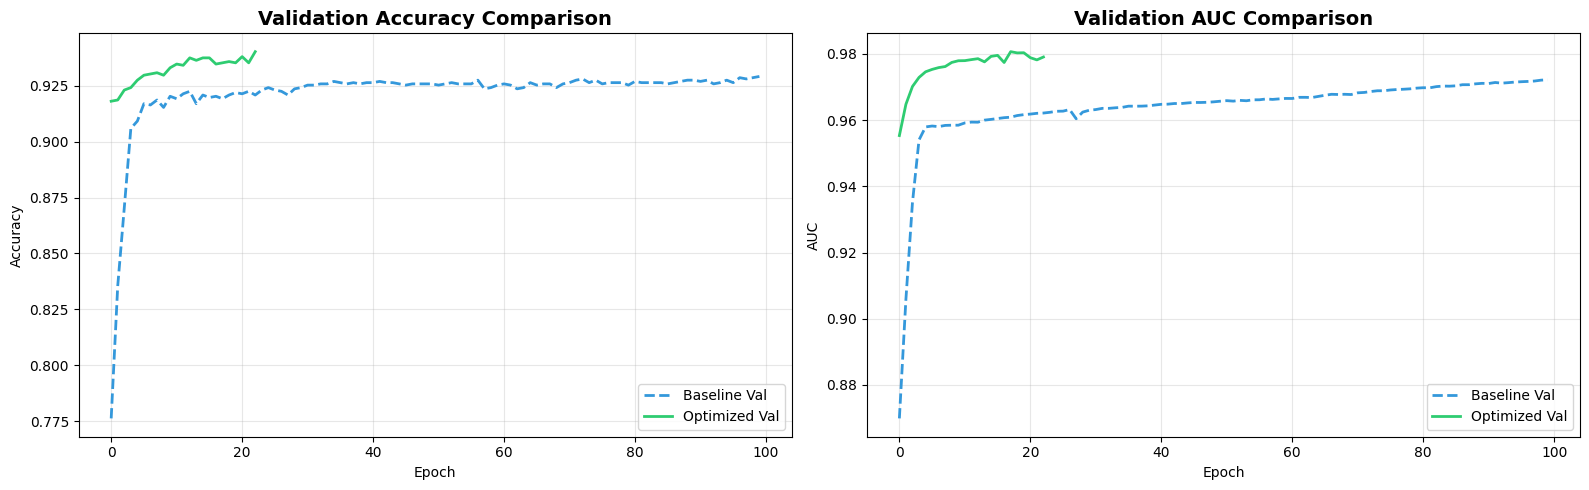

Saved: ./plots/BiGRU_Baseline_training_comparison.png


In [19]:

# Training Curves — Baseline vs Optimized


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("auc", "val_auc")],
    ["Accuracy", "AUC"],
):
    train_key, val_key = metric
    ax.plot(baseline_history.history[val_key],
            label="Baseline Val",    linewidth=2, linestyle="--", color="#3498db")
    ax.plot(optimized_history.history[val_key],
            label="Optimized Val",   linewidth=2, color="#2ecc71")
    ax.set_title(f"Validation {title} Comparison", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
train_cmp_path = f"{DIRS['plots']}/{MODEL_NAME}_training_comparison.png"
plt.savefig(train_cmp_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {train_cmp_path}")


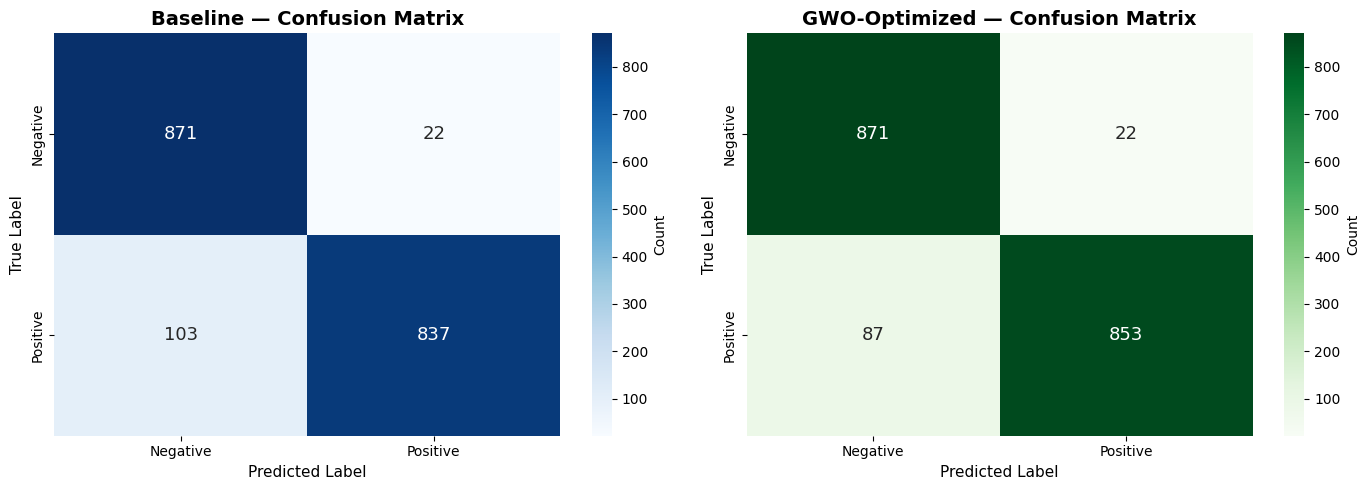

Saved: ./plots/BiGRU_Baseline_confusion_comparison.png


In [20]:

# Confusion Matrices — Baseline vs Optimized (Test Set)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm_obj, title, cmap in zip(
    axes,
    [baseline_test_metrics, optimized_test_metrics],
    ["Baseline", "GWO-Optimized"],
    ["Blues", "Greens"],
):
    sns.heatmap(
        cm_obj.confusion_matrix(), annot=True, fmt="d",
        cmap=cmap, ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        cbar_kws={"label": "Count"}, annot_kws={"size": 13},
    )
    ax.set_title(f"{title} — Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
cm_path = f"{DIRS['plots']}/{MODEL_NAME}_confusion_comparison.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


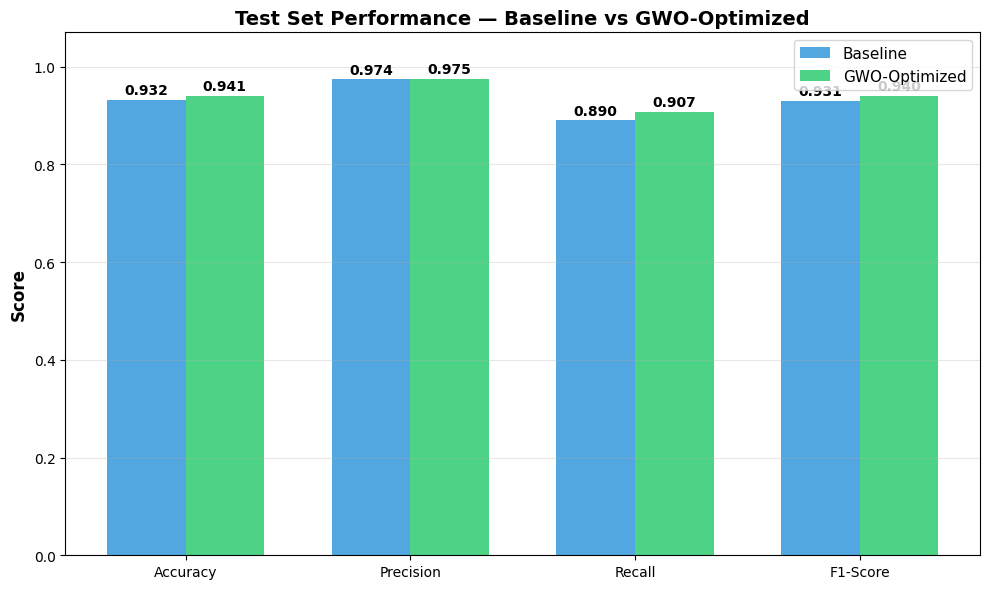

Saved: ./plots/BiGRU_Baseline_metrics_comparison.png


In [21]:

# Metrics Bar Chart — Test Set


metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
base_values   = [baseline_test_metrics.accuracy(), baseline_test_metrics.precision(),
                  baseline_test_metrics.recall(),   baseline_test_metrics.f1()]
opt_values    = [optimized_test_metrics.accuracy(), optimized_test_metrics.precision(),
                  optimized_test_metrics.recall(),   optimized_test_metrics.f1()]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, base_values, width, label="Baseline",      color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, opt_values,  width, label="GWO-Optimized", color="#2ecc71", alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("Test Set Performance — Baseline vs GWO-Optimized", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim([0, 1.07])
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = f"{DIRS['plots']}/{MODEL_NAME}_metrics_comparison.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")


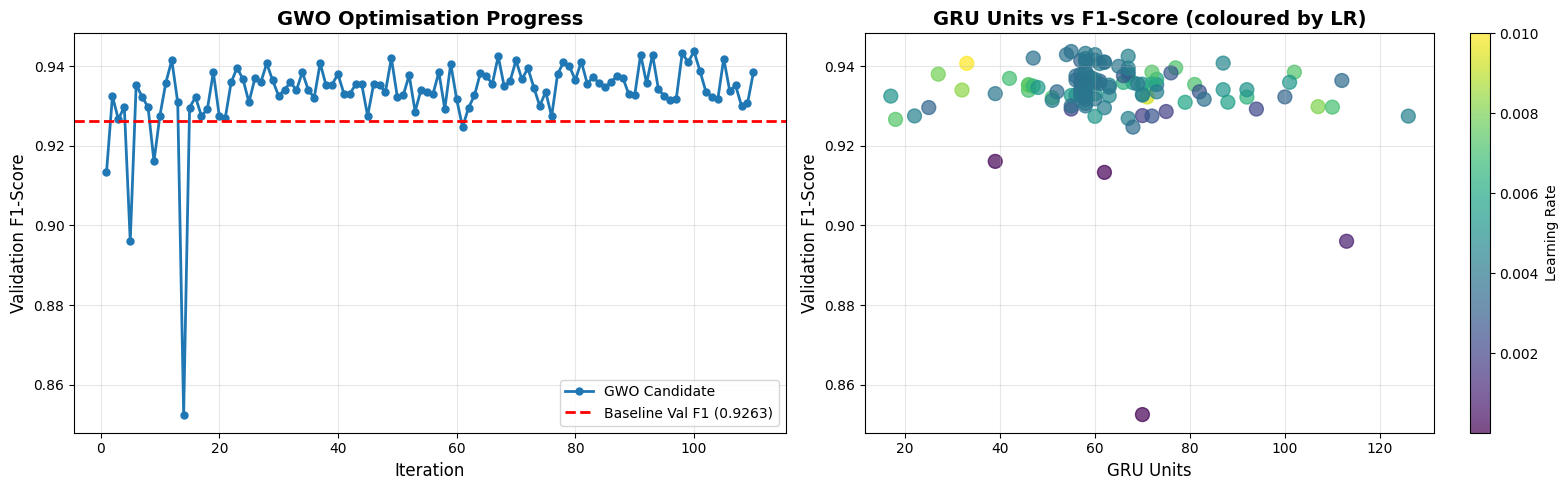

Saved: ./plots/BiGRU_Baseline_gwo_progress.png


In [22]:

# GWO Optimisation Progress


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 over iterations
axes[0].plot(log_df["iteration"], log_df["f1_score"],
             marker="o", linewidth=2, markersize=5, label="GWO Candidate")
axes[0].axhline(y=baseline_val_metrics.f1(), color="r", linestyle="--",
                label=f"Baseline Val F1 ({baseline_val_metrics.f1():.4f})", linewidth=2)
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Validation F1-Score", fontsize=12)
axes[0].set_title("GWO Optimisation Progress", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU units vs F1 (coloured by LR)
sc = axes[1].scatter(
    log_df["gru_units"], log_df["f1_score"],
    s=100, alpha=0.7, c=log_df["learning_rate"], cmap="viridis",
)
plt.colorbar(sc, ax=axes[1], label="Learning Rate")
axes[1].set_xlabel("GRU Units", fontsize=12)
axes[1].set_ylabel("Validation F1-Score", fontsize=12)
axes[1].set_title("GRU Units vs F1-Score (coloured by LR)", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
gwo_prog_path = f"{DIRS['plots']}/{MODEL_NAME}_gwo_progress.png"
plt.savefig(gwo_prog_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {gwo_prog_path}")


In [23]:

# Final Summary

print("" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)

print("[Baseline]")
print(f"  Hyperparams : LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Drop={BASELINE_PARAMS['dropout']}")
print(f"  Test F1     : {baseline_test_metrics.f1():.4f}")
print(f"  Test Acc    : {baseline_test_metrics.accuracy():.4f}")
print(f"  Saved model : {BASELINE_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(baseline_time)))}")

print("[GWO-Optimized]")
print(f"  Hyperparams : LR={best_params['learning_rate']:.2e}  Batch={best_params['batch_size']}  ", end="")
print(f"GRU={best_params['gru_units']}  Drop={best_params['dropout']:.4f}")
print(f"  Test F1     : {optimized_test_metrics.f1():.4f}")
print(f"  Test Acc    : {optimized_test_metrics.accuracy():.4f}")
print(f"  Saved model : {OPTIMIZED_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(optimized_time)))}")

print(f"[Improvement]")
print(f"  F1  : {f1_improvement:+.2f}%")
print(f"  Acc : {acc_improvement:+.2f}%")
print("=" * 70)


EXPERIMENT SUMMARY
[Baseline]
  Hyperparams : LR=0.0003  Batch=256  GRU=32  Drop=0.3
  Test F1     : 0.9305
  Test Acc    : 0.9318
  Saved model : ./models/BiGRU_Baseline_baseline.keras
  Train time  : 0:03:38
[GWO-Optimized]
  Hyperparams : LR=3.72e-03  Batch=81  GRU=55  Drop=0.2500
  Test F1     : 0.9399
  Test Acc    : 0.9405
  Saved model : ./models/BiGRU_Baseline_optimized.keras
  Train time  : 0:01:52
[Improvement]
  F1  : +1.01%
  Acc : +0.94%
